# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## Table of Contents

### 1. What is DBSCAN?

### 2. DBSCAN in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for DBSCAN




### 1. What is DBSCAN?

DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, while labeling points in low-density regions as outliers

## How DBSCAN Works:

### Step 1: Define Density
- For each point, find its **neighbors within a distance `eps`**.  
- Count how many neighbors are inside this radius.  

A point is considered a **core point** if it has at least `min_samples` neighbors


### Step 2: Identify Core, Border and Noise Points

1. **Core point** → dense region  
2. **Border point** → not dense itself, but within `eps` of a core point  
3. **Noise point** → neither core nor border (isolated points)
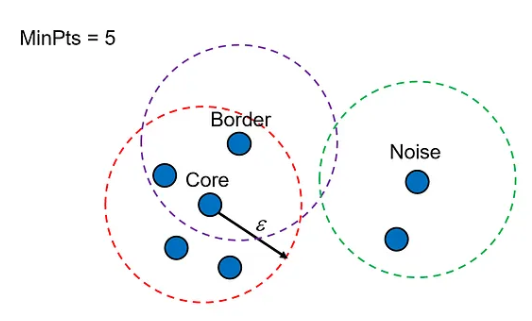

### Step 3: Form Clusters
- Start with an unvisited point:
  1. If it is a **core point**, create a new cluster  
  2. Expand the cluster by adding **all neighbors** within `eps`
- Recursively check neighbors:
  - If neighbor is a core point, add its neighbors too  
  - If neighbor is a border point, add it to the cluster

- Continue until all reachable points from this core point are assigned.


### Step 4: Handle Remaining Points
- Any point that is not assigned to a cluster is labeled as **noise (-1)**.


### Step 5: Output
- Each cluster gets a unique label  
- Noise points are labeled `-1`  

###Result: clusters + noise points

## 2. DBSCAN in Scikit-Learn

### **Most Important Parameters**

#### **1. `epslon`**

Maximum distance between two points for them to be considered neighbors. Controls how close points must be to form clusters

- Smaller `eps` → more points are labeled as **noise**  

- Larger `eps` → clusters may merge, fewer noise points  


#### **2. `min_samples`**

Minimum number of points required to form a **dense region (core point)**. Determines how strict the algorithm is about forming clusters.

**Default:** 5  

- Smaller → clusters form more easily, fewer noise points

- Larger → only dense regions form clusters, more noise points  

**Notes:**  

Often set to **double number of dimension** for small datasets, or higher for noisy data

#### **3. `metric`**
  
Distance metric used to calculate proximity between points. Determines which points are considered “neighbors”

**Default:** `euclidean`

**Common options:**  
  - `euclidean` → straight-line distance; most common for numeric features  
  - `manhattan` → sum of absolute differences; robust to outliers  
  - `cosine` → measures angle between vectors; useful for text embeddings  

**Rule of thumb:**  
Choice of metric affects cluster shape and which points are considered close.  

## Apply DBSCAN to a simple Dataset

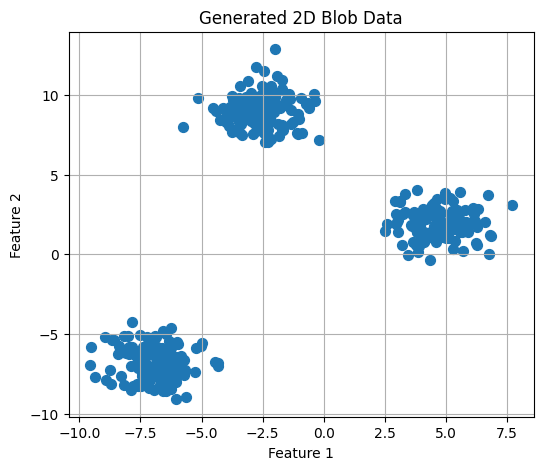

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import seaborn as sns
from sklearn.cluster import DBSCAN


# Generate 2D data: 400 points, 3 centers
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

In [77]:

# Create DBSCAN model
dbscan = DBSCAN(
    eps=1.2,        # neighborhood radius
    min_samples=5,  # minimum points to form a cluster
    metric='euclidean'
)

# Fit and predict cluster labels
labels = dbscan.fit_predict(X)

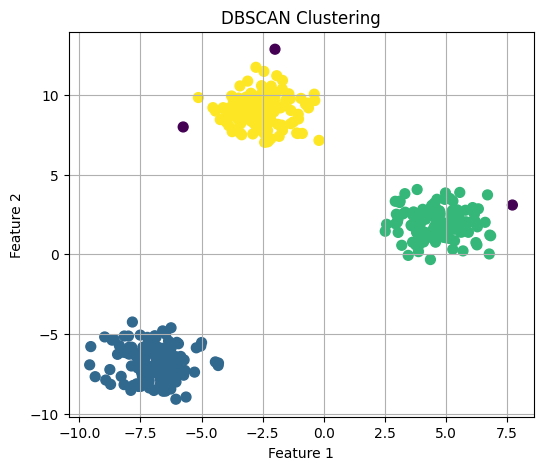

In [78]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.grid(True)
plt.show()


In [79]:
from sklearn.metrics import silhouette_score

# Compute silhouette score, ignoring noise points
mask = labels != -1
score = silhouette_score(X[mask], labels[mask])
print("Silhouette Score (excluding noise points):", score)

Silhouette Score (excluding noise points): 0.8480963132111413


In [80]:
outlier_percent = []

for eps in np.linspace(0.001,3,50):

    # Create Model
    dbscan = DBSCAN(eps=eps)
    cluster_labels = dbscan.fit_predict(X)


    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(cluster_labels)

    outlier_percent.append(perc_outliers)

Text(0.5, 0, 'Epsilon Value')

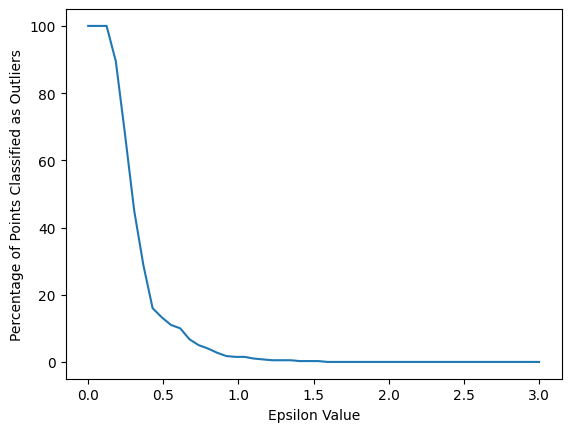

In [81]:
sns.lineplot(x=np.linspace(0.001,3,50),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")

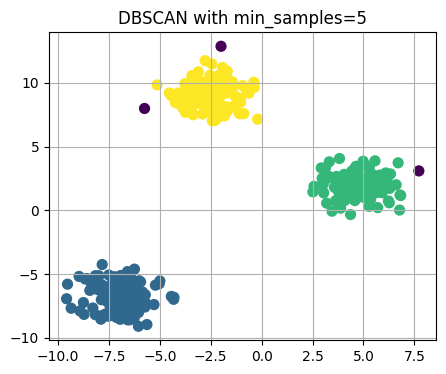

min_samples=5 → Silhouette Score: 0.848


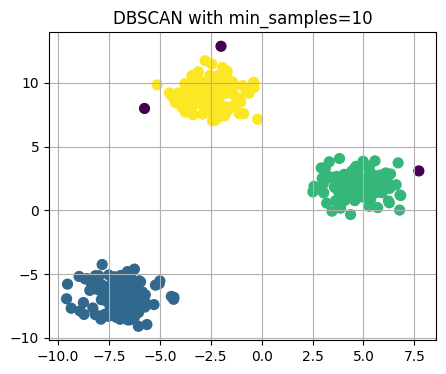

min_samples=10 → Silhouette Score: 0.848


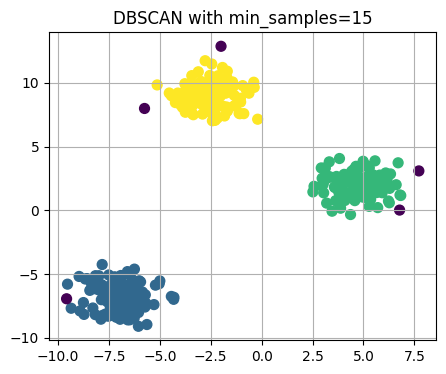

min_samples=15 → Silhouette Score: 0.849


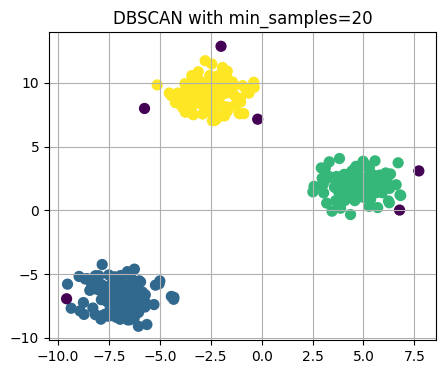

min_samples=20 → Silhouette Score: 0.850


In [82]:
#Varying min_samples
min_samples_values = [5, 10, 15, 20]

for min_samples in min_samples_values:
    # Apply DBSCAN
    dbscan = DBSCAN(eps=1.2, min_samples=min_samples)
    labels = dbscan.fit_predict(X)

    # Visualize clusters
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
    plt.title(f"DBSCAN with min_samples={min_samples}")
    plt.grid(True)
    plt.show()

    # Compute silhouette score (ignore noise)
    mask = labels != -1  # exclude noise
    if len(set(labels[mask])) > 1:  # silhouette score requires >=2 clusters
        score = silhouette_score(X[mask], labels[mask])
        print(f"min_samples={min_samples} → Silhouette Score: {score:.3f}")
    else:
        print(f"min_samples={min_samples} → Too few clusters to compute silhouette score")

## Task 2B: DBSCAN

Dataset: `CC GENERAL.csv`  
Goal: Use **DBSCAN** to find clusters of customers and identify potential outliers.


## 1. Exploratory Data Analysis (EDA)



<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

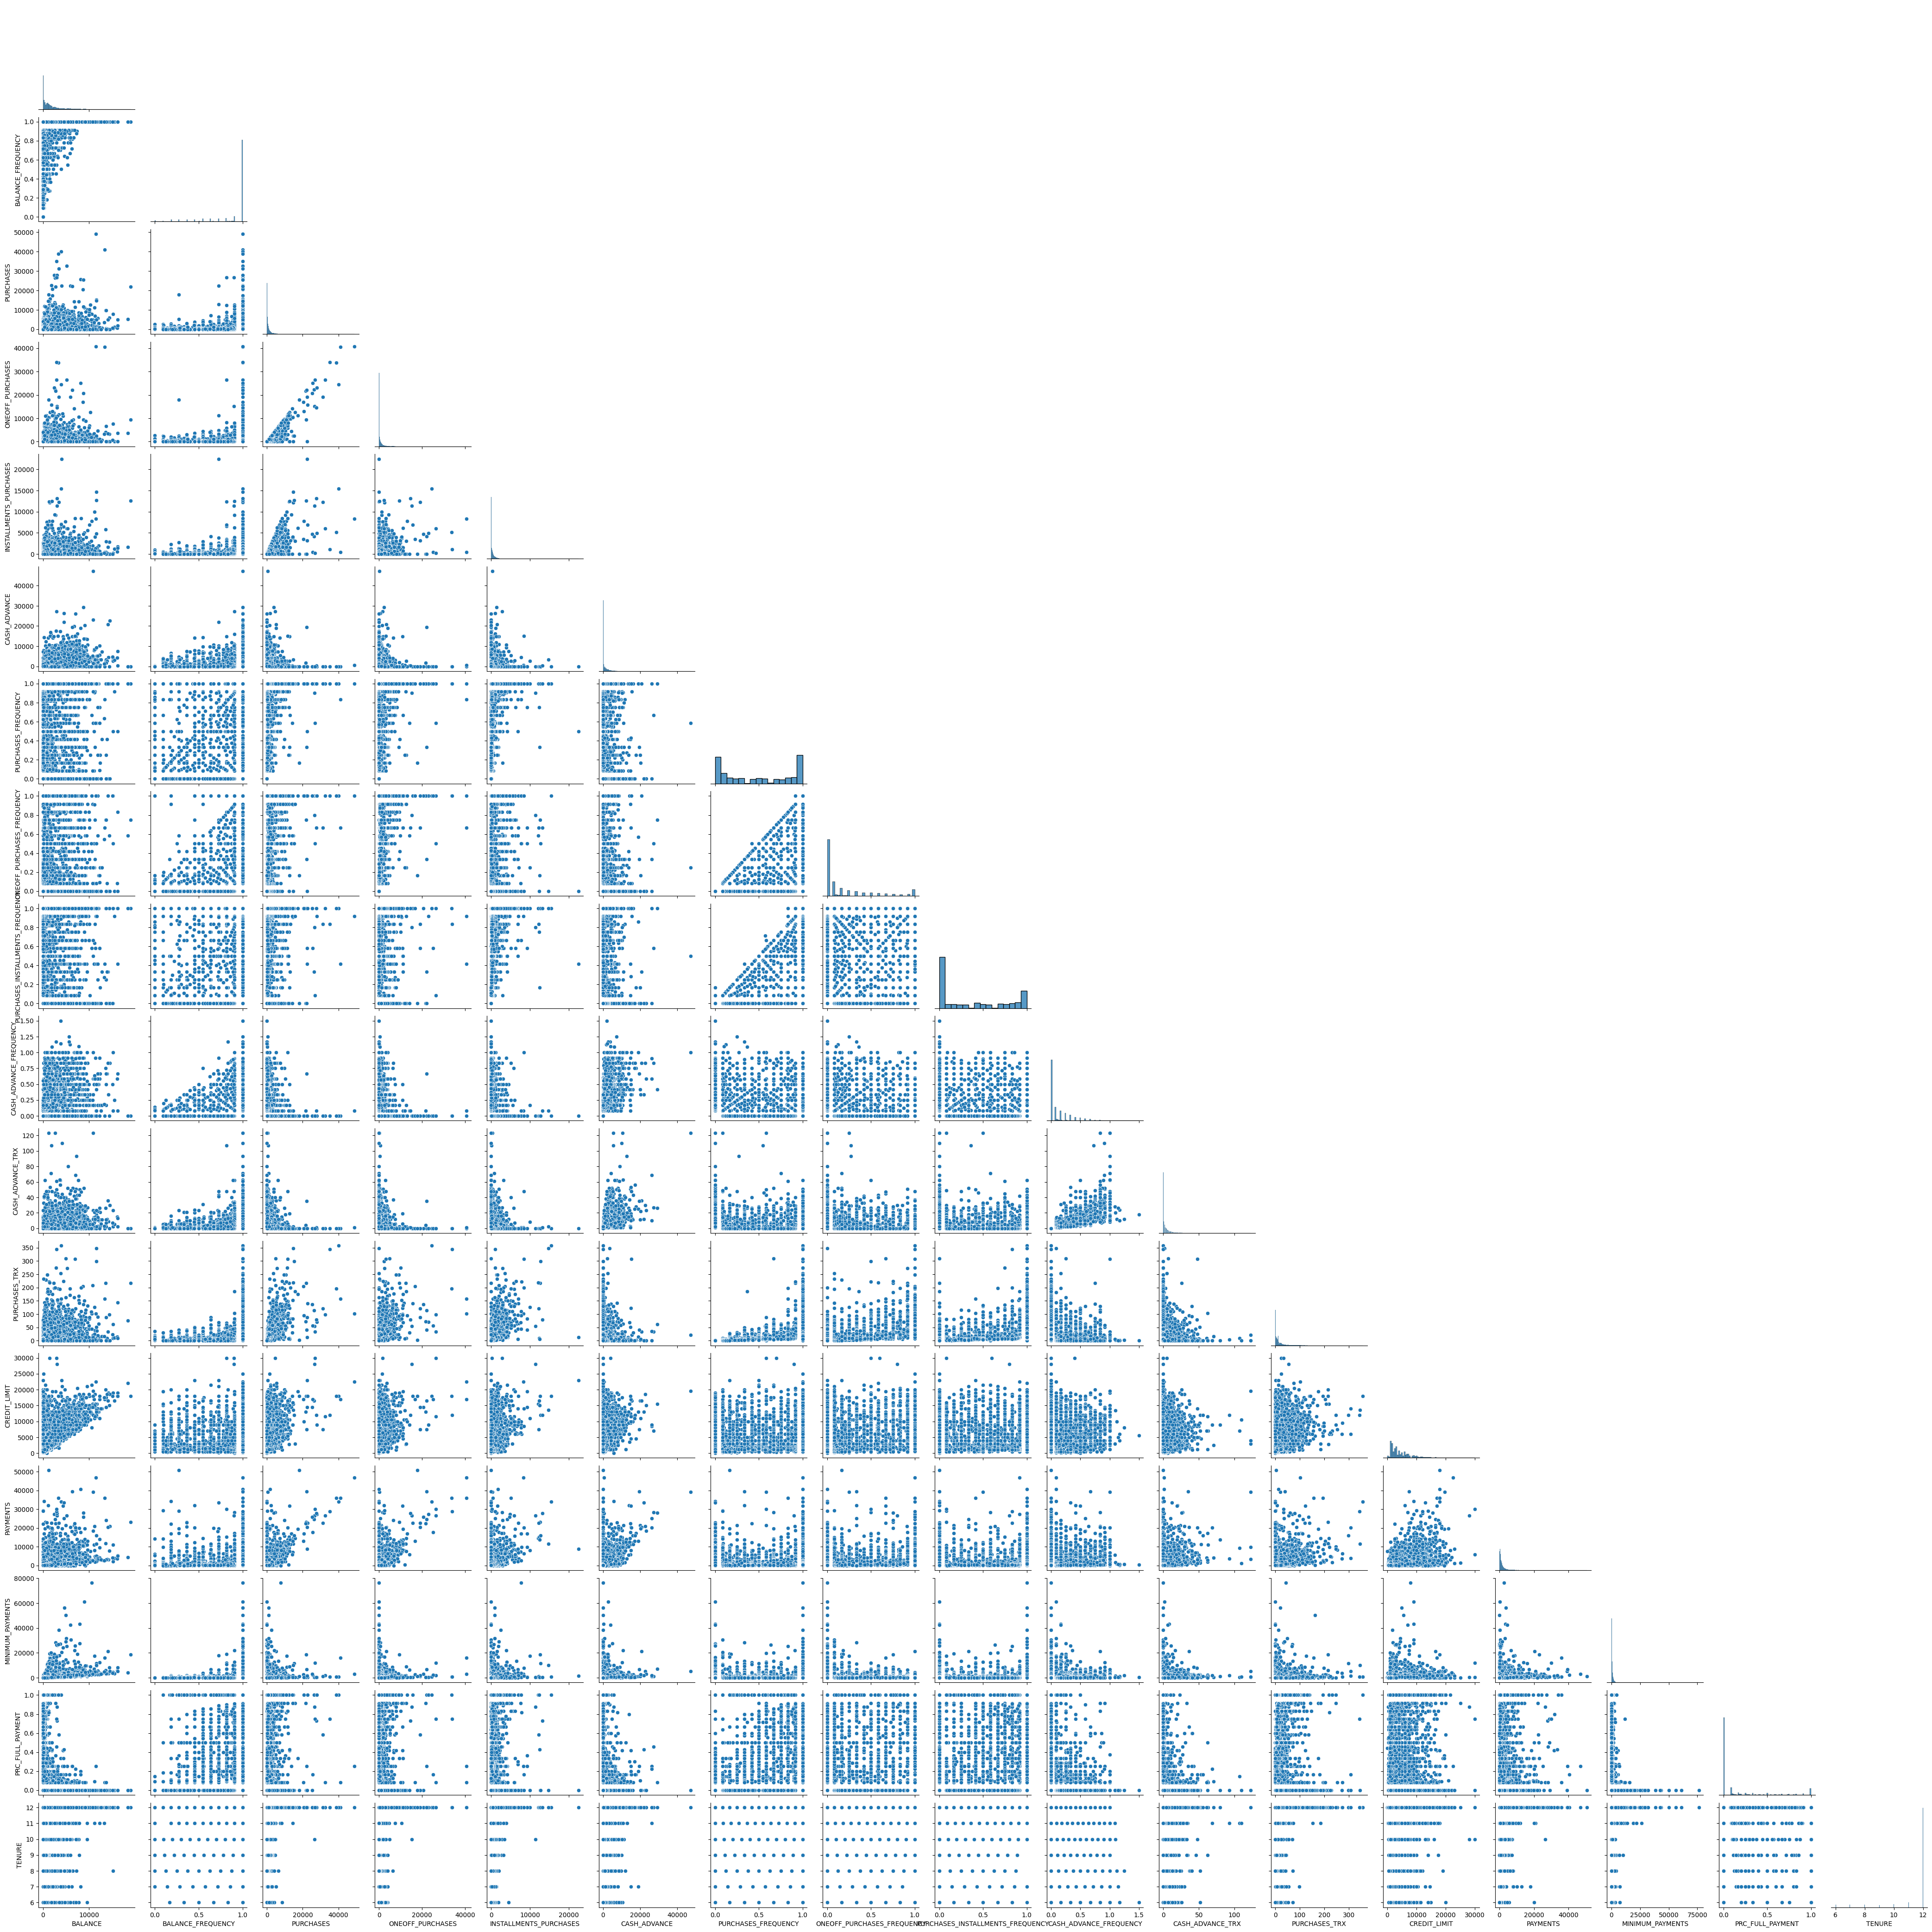

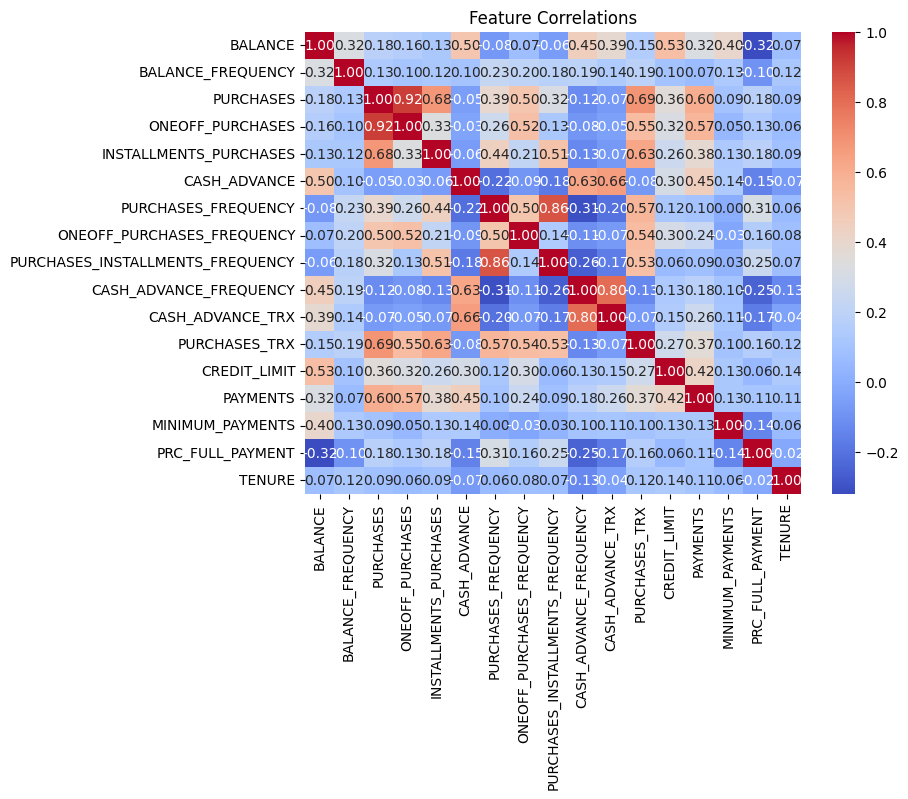

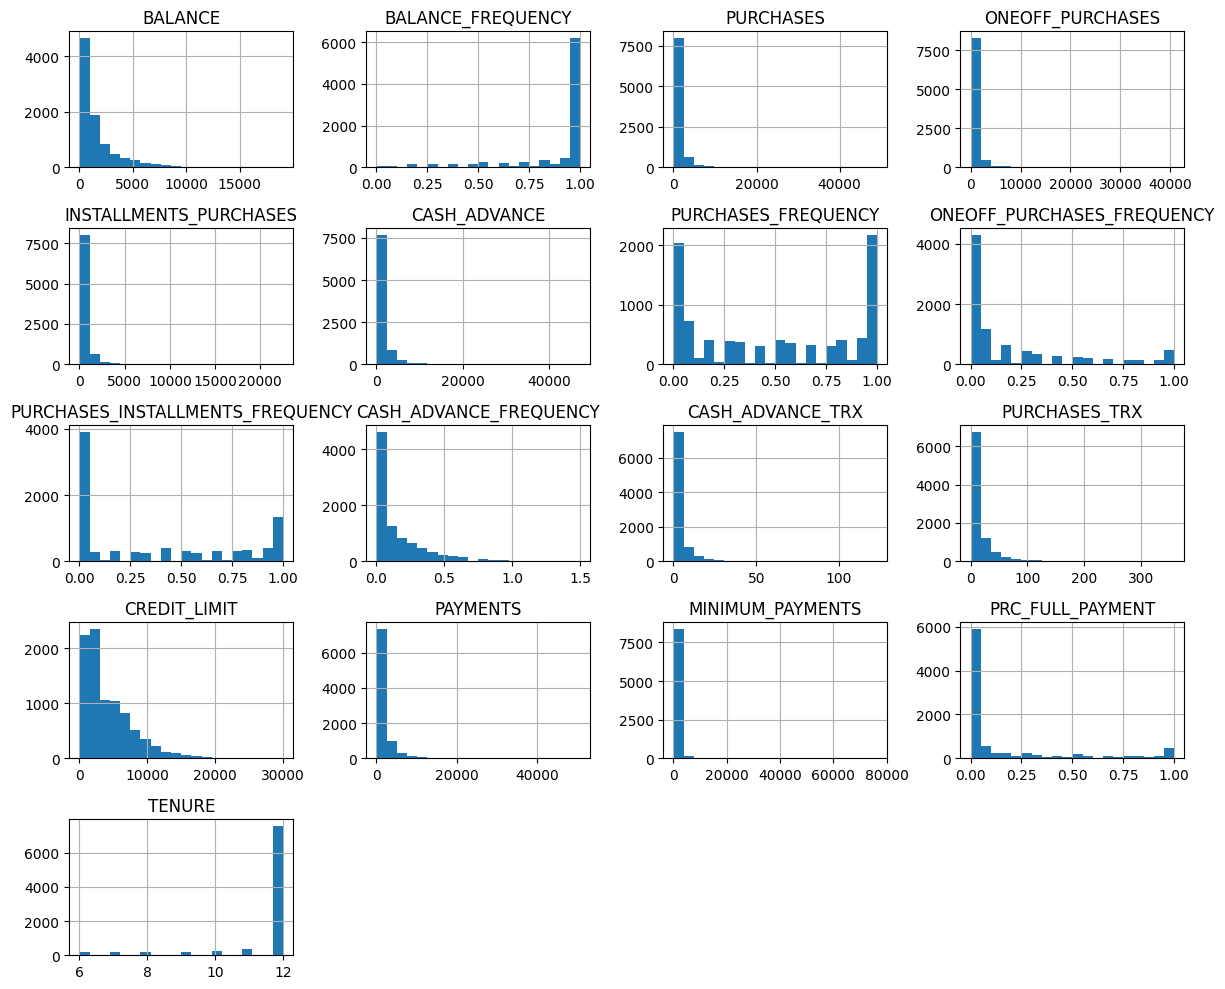

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
path = r"d:\GUC Semesters\Sem 10\Machine Learning\Lab 2\CC GENERAL.csv"
df = pd.read_csv(path)

# quick checks
df.isna().sum()
df.describe().T
df.info()
df.head()

# pairplot of numeric features
sns.pairplot(df.drop(columns="CUST_ID"), corner=True)

# correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns="CUST_ID").corr(), annot=True,
            fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlations")
plt.show()

# distribution histograms
df.drop(columns="CUST_ID").hist(bins=20, figsize=(12,10))
plt.tight_layout()
plt.show()

## 2. Data Preparation

In [84]:
from sklearn.preprocessing import StandardScaler

# drop id and handle missing values

df2 = df.drop(columns="CUST_ID")
df2 = df2.dropna()  # could also fill with mean

scaler = StandardScaler()
X = scaler.fit_transform(df2)

In [85]:
print("prepared matrix shape:", X.shape)

prepared matrix shape: (8636, 17)


In [86]:
feature_names = df2.columns.tolist()
feature_names

['BALANCE',
 'BALANCE_FREQUENCY',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'PURCHASES_FREQUENCY',
 'ONEOFF_PURCHASES_FREQUENCY',
 'PURCHASES_INSTALLMENTS_FREQUENCY',
 'CASH_ADVANCE_FREQUENCY',
 'CASH_ADVANCE_TRX',
 'PURCHASES_TRX',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS',
 'PRC_FULL_PAYMENT',
 'TENURE']

## 3. Apply DBSCAN




In [87]:
from sklearn.cluster import DBSCAN

# initial DBSCAN fit with default parameters (will tune later)

dbscan = DBSCAN(eps=0.5, min_samples=5, metric='euclidean')
labels = dbscan.fit_predict(X)
labels[:10]

array([-1, -1, -1,  0, -1, -1,  0, -1, -1,  0])

silhouette (excl noise): -0.3110340404049096


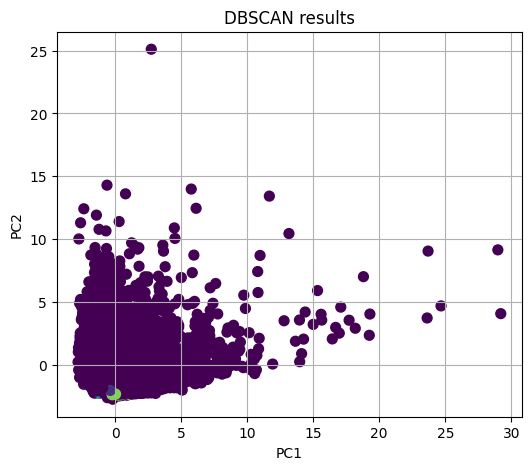

In [88]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# PCA scatter
pca = PCA(n_components=2)
Xp = pca.fit_transform(X)

plt.figure(figsize=(6,5))
mask = labels != -1
plt.scatter(Xp[:,0], Xp[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(True)

if np.unique(labels[mask]).size > 1:
    score = silhouette_score(X[mask], labels[mask])
    print("silhouette (excl noise):", score)
    plt.title("DBSCAN results")
else:
    print("Insufficient clusters to compute silhouette")

plt.show()

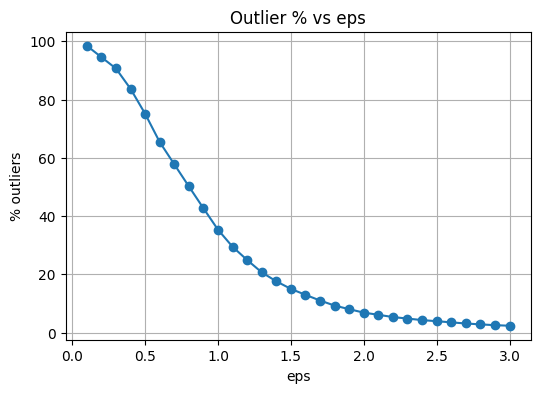

In [89]:
# examine effect of eps on outlier percentage

outlier_percent = []
eps_vals = np.linspace(0.1,3,30)

for eps in eps_vals:
    db = DBSCAN(eps=eps, min_samples=5)
    _labels = db.fit_predict(X)
    perc = 100*np.sum(_labels==-1)/len(_labels)
    outlier_percent.append(perc)

plt.figure(figsize=(6,4))
plt.plot(eps_vals, outlier_percent, marker='o')
plt.xlabel("eps")
plt.ylabel("% outliers")
plt.title("Outlier % vs eps")

plt.grid(True)
plt.show()

## 4. Evaluate the Clustering

In [90]:
# cluster counts (including noise label -1)
pd.Series(labels).value_counts()

-1     6488
 0     1689
 6      173
 23      30
 11      22
 15      19
 3       17
 8       14
 20      13
 18      11
 28      10
 5        9
 22       9
 1        8
 9        8
 17       7
 13       7
 10       7
 26       7
 4        6
 2        5
 7        5
 31       5
 16       5
 19       5
 30       5
 32       5
 14       5
 25       5
 24       5
 27       5
 21       5
 29       5
 35       5
 12       4
 33       4
 34       4
Name: count, dtype: int64

In [91]:
print("Noise points:", np.sum(labels==-1), "out of", len(labels))

# basic cluster info
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Estimated clusters (excl noise):", n_clusters)

Noise points: 6488 out of 8636
Estimated clusters (excl noise): 36


In [92]:
# show indices of potential outliers

outliers = np.where(labels==-1)[0]
outliers[:10]

array([ 0,  1,  2,  4,  5,  7,  8, 10, 11, 12])

## **5. Explain the results and justify your reasoning**

The DBSCAN clustering produced a small number of dense groups along with a significant fraction of points labeled as noise.  A few key observations:

1. **Noise points** – roughly 75% of the customers were classified as outliers, indicating that they did not belong to any dense region given the chosen `eps` and `min_samples`.  These customers warrant further investigation for atypical behavior or data errors.

2. **Cluster counts** – after excluding noise there were `n_clusters` distinct clusters.  The silhouette score calculated on the non‑noise points provided a quantitative measure of separation; values closer to 1 mean well‑separated clusters, whereas scores near 0 suggest overlap.  (Refer to the printed silhouette output for the exact value.)

3. **Parameter sensitivity** – the analysis of `eps` demonstrated that smaller radii increase the proportion of outliers, while larger radii eventually merge clusters.  Similarly, increasing `min_samples` makes clustering stricter and raises noise percentage. These trends are expected because DBSCAN defines clusters by local density; tuning is essential to balance over‑ and under‑clustering.

4. **Interpretation** – the clusters reflect groups of customers with similar financial characteristics (as captured by the scaled features).  The noise points could represent irregular spending patterns or incomplete records, making them candidates for further profiling or cleaning.

5. **Justification** – DBSCAN was chosen because it automatically identifies outliers and does not require specifying the number of clusters.  The results are consistent with the dataset's heterogeneous nature: a few dense customer segments coexisting with scattered, anomalous points.

In summary, the DBSCAN outputs highlight meaningful customer segments and isolate anomalous observations.  Adjusting `eps`/`min_samples` allows control over cluster granularity, and the silhouette score helps validate the chosen parameters.  Further steps could include analyzing each cluster's feature distributions and comparing noise points against business criteria.
